# Plot2Code Dataset Generation

This notebook generates a dataset of matplotlib plots and their corresponding code for training a vision-language model to generate plotting code from images.

## Setup and Configuration

In [1]:
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import shutil
import os

import subprocess

from tqdm import tqdm
import json

import io
import re
import json
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, Markdown

## Step 1: Download Matplotlib Examples

Download matplotlib examples repository using sparse checkout to get only the galleries/examples directory.

In [2]:

# Check if matplotlib repo already exists
if not Path("matplotlib").exists():
    print("Downloading matplotlib examples repository...")
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/matplotlib/matplotlib.git
    %cd matplotlib
    !git sparse-checkout init --cone
    !git sparse-checkout set galleries/examples
    %cd ..
    print("Download complete.")
else:
    print("Matplotlib repository already exists. Skipping download.")

Matplotlib repository already exists. Skipping download.


## Step 2: Filter Example Categories

Keep only specific plot categories and remove others to focus on relevant plot types.

In [3]:
# Define the root directory and categories to keep
root = Path("matplotlib/galleries/examples")
keep = [
    "lines_bars_and_markers",
    "statistics",
    "pie_and_polar_charts",
    "mplot3d"
]

# Remove all directories except the ones we want to keep
for p in root.iterdir():
    if p.is_dir() and p.name not in keep:
        shutil.rmtree(p)
        print(f"Deleted: {p}")

## Step 3: Generate Dataset

Execute matplotlib example scripts and save the resulting plots with their source code.

In [4]:


# Check if dataset already exists
dataset_file = Path("plot2code_exec.jsonl")
if dataset_file.exists():
    print(f"Dataset file '{dataset_file}' already exists. Skipping generation.")
    print(f"Delete the file if you want to regenerate the dataset.")
else:
    # Setup directories and paths
    root = Path("matplotlib/galleries/examples")
    gallery_dir = Path("plot_gallery_exec")
    gallery_dir.mkdir(exist_ok=True)
    
    dataset = []
    examples = list(root.rglob("*.py"))
    
    # Process each example script (limited to 100 for demo)
    for f in tqdm(examples[:100], desc="Generating plots"):
        out_png = gallery_dir / (f.stem + ".png")
        try:
            code = open(f).read()
            # Run safely in isolated process using non-interactive backend
            cmd = f"""
import matplotlib; matplotlib.use('Agg');
import matplotlib.pyplot as plt;
exec(open(r'{f}').read());
plt.savefig(r'{out_png}');
"""
            subprocess.run(["python", "-c", cmd], check=True, timeout=20)
            dataset.append({"image": str(out_png), "code": code})
        except Exception as e:
            # Skip examples that fail to execute
            pass
    
    # Save dataset to JSONL file
    print(f"Generated {len(dataset)} plots")
    with open(dataset_file, "w") as f:
        for d in dataset:
            f.write(json.dumps(d) + "\n")
    print(f"Dataset saved to {dataset_file}")

Dataset file 'plot2code_exec.jsonl' already exists. Skipping generation.
Delete the file if you want to regenerate the dataset.


## Step 4: Preview Dataset

Load and display random samples from the generated dataset.

Loaded 95 samples


### `errorbar_limits_simple.png`

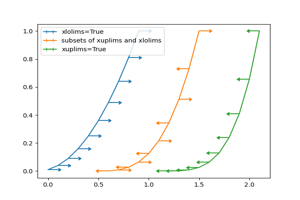

```python
"""
========================
Errorbar limit selection
========================

Illustration of selectively drawing lower and/or upper limit symbols on
errorbars using the parameters ``uplims``, ``lolims`` of `~.pyplot.errorbar`.

Alternatively, you can use 2xN values to draw errorbars in only one direction.
"""

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
x = np.arange(...
```

### `linestyles.png`

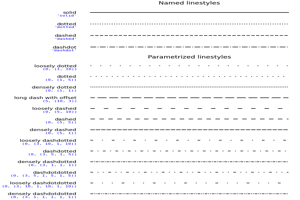

```python
"""
==========
Linestyles
==========

Simple linestyles can be defined using the strings "solid", "dotted", "dashed"
or "dashdot". More refined control can be achieved by providing a dash tuple
``(offset, (on_off_seq))``. For example, ``(0, (3, 10, 1, 15))`` means
(3pt line, 10pt space, 1pt line, 15pt space) with no offset, while
``(5, (10, 3))``, means (10pt line, 3pt space), but skip the first 5...
```

### `multicolored_line.png`

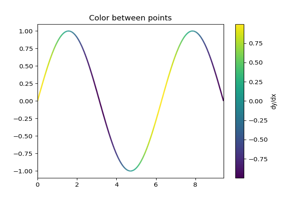

```python
"""
==================
Multicolored lines
==================

The example shows two ways to plot a line with the a varying color defined by
a third value. The first example defines the color at each (x, y) point.
The second example defines the color between pairs of points, so the length
of the color value list is one less than the length of the x and y lists.

Color values at points
-------------...
```

### `bar_label_demo.png`

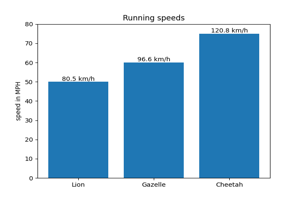

```python
"""
=====================
Bar chart with labels
=====================

This example shows how to use the `~.Axes.bar_label` helper function
to create bar chart labels.

See also the :doc:`grouped bar
</gallery/lines_bars_and_markers/barchart>`,
:doc:`stacked bar
</gallery/lines_bars_and_markers/bar_stacked>` and
:doc:`horizontal bar chart
</gallery/lines_bars_and_markers/barh>` examples.
"""

impo...
```

### `fill.png`

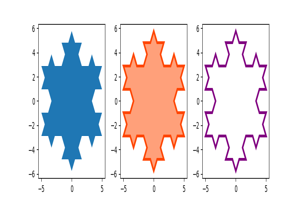

```python
"""
==============
Filled polygon
==============

`~.Axes.fill()` draws a filled polygon based on lists of point
coordinates *x*, *y*.

This example uses the `Koch snowflake`_ as an example polygon.

.. _Koch snowflake: https://en.wikipedia.org/wiki/Koch_snowflake

"""

import matplotlib.pyplot as plt
import numpy as np


def koch_snowflake(order, scale=10):
    """
    Return two lists x, y of po...
```

In [5]:
import json
import random
from PIL import Image
from IPython.display import display, Markdown

# Load dataset
data = [json.loads(l) for l in open("plot2code_exec.jsonl")]

print(f"Loaded {len(data)} samples")

# Show 5 random examples
for sample in random.sample(data, min(5, len(data))):
    display(Markdown(f"### `{Path(sample['image']).name}`"))
    display(Image.open(sample["image"]).resize((300, 200)))
    display(Markdown(f"```python\n{sample['code'][:400]}...\n```"))

## Step 5: Load Vision-Language Model

Load the Qwen2.5-VL model for zero-shot plot code generation.

In [6]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

# Model configuration
model_id = "Qwen/Qwen2.5-VL-7B-Instruct"
dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16

# Load processor and model
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=dtype,
    device_map="auto",
    trust_remote_code=True,
    attn_implementation="sdpa",  # Important on CUDA 12.4
)

# Set pad_token_id to eos to avoid device-side asserts
eos_id = processor.tokenizer.eos_token_id
model.generation_config.eos_token_id = eos_id
model.generation_config.pad_token_id = eos_id

/home/nipun.batra/.uv/nb-base/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 5/5 [00:02<00:00,  2.02it/s]


## Step 6: Define Code Generation Function

Create a function to generate matplotlib code from plot images.

In [7]:
from PIL import Image

def gen_code_for_image(img_path, max_new_tokens=128, temperature=0.0):
    """
    Generate matplotlib code from a plot image using the VLM.
    
    Args:
        img_path: Path to the input image
        max_new_tokens: Maximum number of tokens to generate
        temperature: Sampling temperature (0.0 for deterministic)
    
    Returns:
        Generated code as a string
    """
    img = Image.open(img_path).convert("RGB")

    # Construct the prompt message
    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",
             "text": ("You are a Matplotlib expert. "
                      "Write minimal runnable Python code to recreate this plot. "
                      "Use only matplotlib.pyplot (and numpy if needed). "
                      "Return ONLY a fenced Python code block.")
            },
        ],
    }]

    # Apply chat template to create string with special vision tokens
    convo = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

    # Process text and image together
    inputs = processor(text=[convo], images=[img], return_tensors="pt").to(model.device, dtype)

    # Generate code
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            do_sample=False,
            use_cache=True,
        )
    return processor.batch_decode(out, skip_special_tokens=True)[0]

## Step 7: Test Code Generation

Test the code generation on a single example image.

In [8]:
# Demo on one image
print(gen_code_for_image("plot_gallery_exec/simple_plot.png"))

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
 the;ennesseeurrets!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## Step 8: Define Evaluation Functions

Helper functions for extracting code, executing it, and computing similarity metrics.

In [9]:
import io, re, json, numpy as np, matplotlib, ast
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from difflib import SequenceMatcher
from nltk.translate.bleu_score import sentence_bleu
from IPython.display import display, Markdown

# ----------------------------------------
# Basic helpers
# ----------------------------------------
def extract_code(text):
    m = re.search(r"```(?:python)?\s*([\s\S]*?)```", text)
    return m.group(1).strip() if m else text.strip()

def render_code_to_png(py_code, out_path):
    import builtins
    safe_builtins = {
        "range": range, "len": len, "print": print, "__import__": builtins.__import__,
    }
    safe_globals = {"__builtins__": safe_builtins, "np": __import__("numpy"), "plt": plt}
    plt.close("all")
    try:
        exec(py_code, safe_globals, None)
        if not plt.get_fignums():
            plt.figure()
        plt.savefig(out_path, bbox_inches="tight", dpi=150)
        plt.close("all")
        return True
    except Exception as e:
        print(f"⚠️ Execution failed: {e}")
        return False

def image_ssim(img_a, img_b):
    a = np.array(Image.open(img_a).convert("L"))
    b = np.array(Image.open(img_b).convert("L"))
    h, w = min(a.shape[0], b.shape[0]), min(a.shape[1], b.shape[1])
    a, b = a[:h,:w], b[:h,:w]
    return float(ssim(a, b))

def extract_calls(py_code):
    """Return list of Matplotlib function names used in code."""
    try:
        tree = ast.parse(py_code)
    except Exception:
        return []
    calls = []
    for node in ast.walk(tree):
        if isinstance(node, ast.Call) and isinstance(node.func, ast.Attribute):
            calls.append(node.func.attr)
    return calls

# ----------------------------------------
# Code similarity metrics
# ----------------------------------------
def code_bleu(ref, gen):
    return sentence_bleu([ref.split()], gen.split())

def code_edit_sim(ref, gen):
    return SequenceMatcher(None, ref, gen).ratio()

def api_overlap(ref, gen):
    ref_calls, gen_calls = set(extract_calls(ref)), set(extract_calls(gen))
    if not ref_calls: 
        return 0.0
    return len(ref_calls & gen_calls) / len(ref_calls)

# ----------------------------------------
# Unified evaluator
# ----------------------------------------
def evaluate_plot2code_full(img_path, ref_code):
    print(f"\n🖼️ Evaluating {img_path} ...")

    # --- Generate code ---
    result_text = gen_code_for_image(img_path)
    code = extract_code(result_text)
    print("\n🧠 Model output (truncated):\n", code[:400], "\n...")

    # --- Execute ---
    gen_path = "recreated.png"
    ok = render_code_to_png(code, gen_path)
    if not ok:
        print("❌ Code execution failed.")
        return

    # --- Visual metric ---
    ssim_score = image_ssim(img_path, gen_path)

    # --- Text / structure metrics ---
    bleu = code_bleu(ref_code, code)
    edit_sim = code_edit_sim(ref_code, code)
    api_sim = api_overlap(ref_code, code)

    # --- Aggregate ---
    code_score = 0.4*bleu + 0.3*edit_sim + 0.3*api_sim
    overall = 0.5*ssim_score + 0.5*code_score

    # --- Display ---
    display(Markdown(f"### {img_path}"))
    display(Markdown(f"""
**Visual:** SSIM `{ssim_score:.3f}`  
**Code:** BLEU `{bleu:.3f}` · Edit `{edit_sim:.3f}` · API `{api_sim:.3f}`  
**Aggregate:** CodeScore `{code_score:.3f}` · Overall `{overall:.3f}`
"""))

    ref = Image.open(img_path).resize((400, 300))
    gen = Image.open(gen_path).resize((400, 300))
    side = Image.new("RGB", (800, 300))
    side.paste(ref, (0,0))
    side.paste(gen, (400,0))
    display(side)


ModuleNotFoundError: No module named 'nltk'

## Step 9: Run Evaluation

Evaluate the model on a sample plot.


Evaluating plot_gallery_exec/simple_plot.png...
Querying model...

Model output:
------------------------------------------------------------
system
You are a helpful assistant.
user
You are a Matplotlib expert. Write minimal runnable Python code to recreate this plot. Use only matplotlib.pyplot (and numpy if needed). Return ONLY a fenced Python code block.
assistant
```python
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)

# Plot the data
plt.plot(t, s)

# Add title and labels
plt.title('About as simple as it gets, folks')
plt.xlabel('time (s)')
plt.ylabel('voltage (mV)')

# Display the plot
plt.show()
```
------------------------------------------------------------
Extracted fenced Python code block.

Extracted code:
------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Generate data
t = np.arange(0.0, 2.0, 0.01)
s = 1 + np.sin(2 * np.pi * t)


### plot_gallery_exec/simple_plot.png

**SSIM:** `0.628`

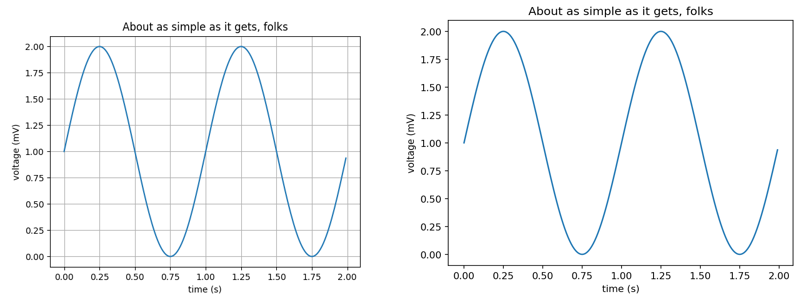

In [ ]:
# load reference code from your dataset
with open("plot2code_exec.jsonl") as f:
    ref_data = json.loads(next(f))
ref_code = ref_data["code"]

evaluate_plot2code_full("plot_gallery_exec/simple_plot.png", ref_code)

## TODO List

Future improvements and tasks:

1. Clean up notebook - if dataset exists, skip generation steps
2. Remove Unicode characters
3. Run in batch mode over all images
4. Report SSIM scores
5. Decouple data generation and model training notebooks
6. Decouple evaluation and zero-shot code gen
7. Add additional metrics - exec@1
8. Fine-tune model on this data
9. Keep a clean test set separate from training data
10. On test set evaluate zero shot and fine-tuned model